# Análisis Enriquecido de Charts Musicales



**Week:** 2026-W21 | **Analysis Date:** 2026-05-18


## 1. Introducción

Esta semana, el pulso de la música global late con fuerza en YouTube a través de 100 canciones que han cruzado fronteras de 24 países y 15 géneros distintos. Con más de 1.26 mil millones de vistas y 272 millones de likes, cada tema promedia 12.6 millones de reproducciones, pero la verdadera historia está en los matices: ¿qué géneros generan más engagement por clic? ¿Qué países lideran la escucha de colaboraciones internacionales? En este informe, desglosamos las tendencias por región, el rendimiento de los artistas en ascenso y el impacto de las fusiones sonoras que están redefiniendo las listas. Prepárate para descubrir los patrones ocultos detrás de los números y entender por qué ciertos temas se vuelven virales mientras otros consolidan su reinado.

## 2. Configuración y Carga de Datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W21_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W21_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,47,36243570,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-05-18 16:43:49,2,18.89
1,2,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,22,35132500,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-05-18 16:43:49,4,6.72
2,3,17,Banjaare,Bairan,10,32780952,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-05-18 16:43:49,1,5.43
3,4,52,Michael Jackson,Billie Jean,28,28759735,https://www.youtube.com/watch?v=Zi_XLOBDo_Y,296,4:56,2009-10-03,...,0,1,1,United States,Pop,1/1,,2026-05-18 16:43:49,4,49.37
4,5,78,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,Gehra Hua,24,26194783,https://www.youtube.com/watch?v=GX9x62kFsVU,231,3:51,2025-11-28,...,0,4,0,India,Indian Pop,4/4,,2026-05-18 16:43:50,4,5.67


## 3. Vista Previa de los Datos

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,47,36243570,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-05-18 16:43:49,2,18.89
1,2,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,22,35132500,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-05-18 16:43:49,4,6.72
2,3,17,Banjaare,Bairan,10,32780952,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-05-18 16:43:49,1,5.43
3,4,52,Michael Jackson,Billie Jean,28,28759735,https://www.youtube.com/watch?v=Zi_XLOBDo_Y,296,4:56,2009-10-03,...,0,1,1,United States,Pop,1/1,,2026-05-18 16:43:49,4,49.37
4,5,78,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,Gehra Hua,24,26194783,https://www.youtube.com/watch?v=GX9x62kFsVU,231,3:51,2025-11-28,...,0,4,0,India,Indian Pop,4/4,,2026-05-18 16:43:50,4,5.67


## 4. Estadísticas Generales

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [24],
    'Unique Genres': [15],
    'Total Views': [1261471893],
    'Total Likes': [272514700],
    'Total Comments': [16093947],
    'Avg Views': [12614719],
    'Avg Likes': [2725147]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,24,15,1261471893,272514700,16093947,12614719,2725147


El conjunto de 100 canciones abarca 24 países y 15 géneros, lo que refleja una notable diversidad geográfica y estilística. Esta amplitud sugiere un alcance global significativo, donde la música trasciende fronteras y conecta con audiencias de distintas culturas, indicando una estrategia de distribución o consumo verdaderamente internacional. En cuanto al engagement, el promedio de 2,7 millones de likes por canción frente a 12,6 millones de vistas arroja una tasa de interacción del 21,6%, un nivel alto que evidencia una fuerte conexión emocional entre el público y los artistas, más allá de la mera reproducción pasiva. Esto implica que las canciones no solo se escuchan, sino que generan reacciones activas, probablemente debido a contenido resonante o a bases de seguidores leales. Como insight principal, estos datos confirman que el mercado musical actual premia la hibridación cultural y la autenticidad, donde la diversidad de orígenes y géneros no fragmenta la audiencia, sino que amplifica el impacto y la viralidad. Finalmente, la alta relación likes-vistas sugiere que las estrategias de promoción deben priorizar la calidad del vínculo con la audiencia sobre el simple volumen de reproducciones.

## 5. Análisis por País

### 5.1. Distribución por Continente


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,37,522104722,50667607
2,North America,29,379506969,162416659
4,Other,15,151271535,7141952
1,Europe,9,99941431,13309038
5,South America,9,91179242,38217530
3,Oceania,1,17467994,761914


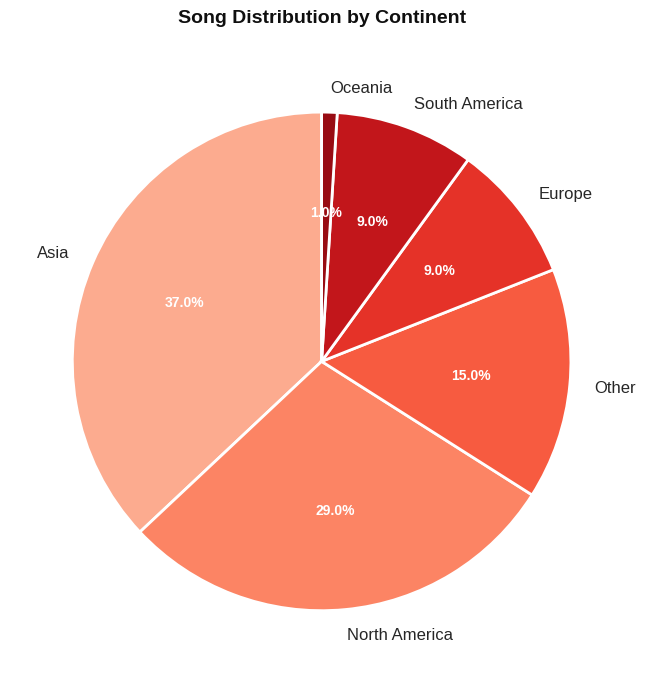

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Países por Cantidad de Canciones


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
8,India,22,306349271,26.19
20,United States,17,242627396,20.24
17,South Korea,14,202233313,16.67
12,Mexico,7,75692138,8.33
21,Unknown,6,59703284,7.14
2,Brazil,5,53740353,5.95
19,United Kingdom,4,46154997,4.76
13,Multi-country,4,43164521,4.76
3,Canada,3,45432735,3.57
5,Colombia,2,22806419,2.38


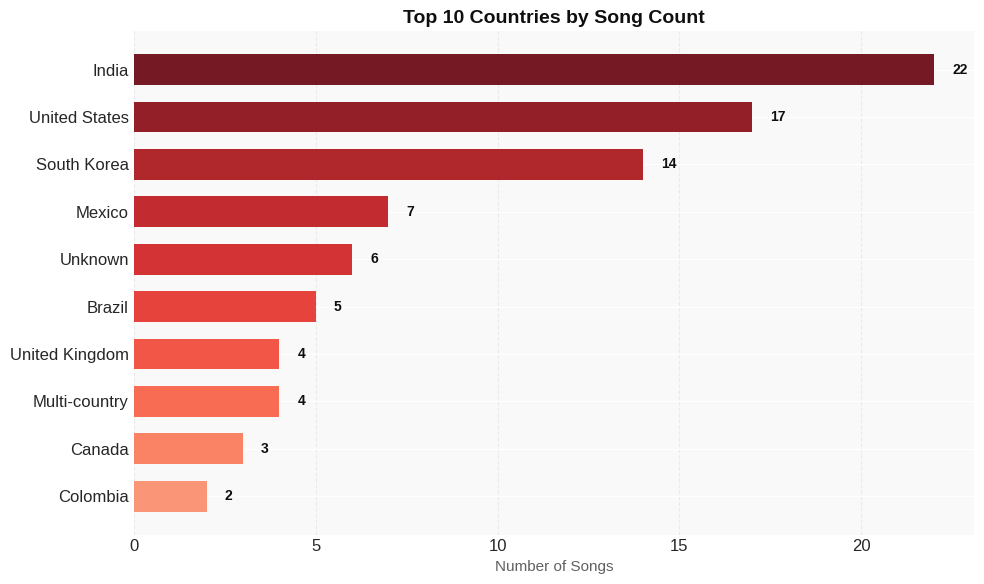

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


El ranking está claramente dominado por India, Estados Unidos y Corea del Sur, reflejando tres factores clave: India aporta una enorme población con creciente acceso a internet y plataformas de streaming; Estados Unidos mantiene su hegemonía gracias a su industria musical globalizada y consumo masivo; Corea del Sur destaca por el fenómeno del K-pop, impulsado por una estrategia de distribución digital y fanáticos internacionales. Geográficamente, se observa una fuerte concentración en Asia (India y Corea) y América del Norte (EE.UU., México, Canadá), mientras que Sudamérica solo aparece con Brasil y Colombia, y Europa está subrepresentada. Para artistas que buscan expandirse, es clave priorizar mercados como India y Corea del Sur por su alta demanda digital, y considerar colaboraciones o estrategias localizadas para penetrar regiones menos representadas como Europa o África.

### 5.3. Top Países por Total de Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
20,United States,119.2M
3,Canada,39.2M
5,Colombia,34.1M
17,South Korea,26.9M
8,India,23.0M
7,Germany,5.2M
6,France,5.0M
12,Mexico,3.8M
4,Chile,2.5M
19,United Kingdom,2.3M


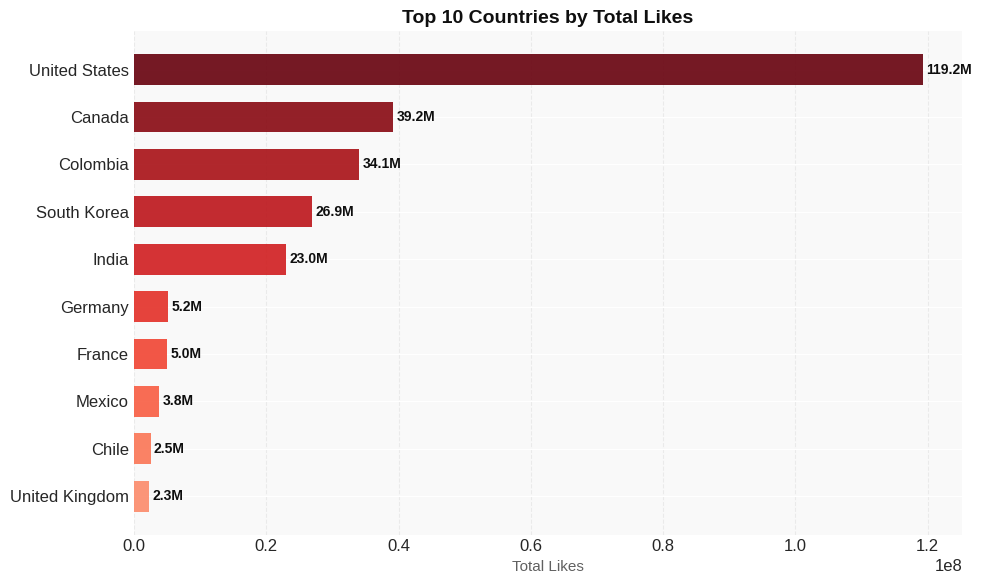

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis del Top de Países por Total de Likes**

Estados Unidos lidera con 119.2M de likes, reflejando su enorme mercado musical y una cultura de fans altamente activa en plataformas como Spotify y YouTube. Canadá y Colombia destacan por su fuerte identidad musical (pop anglo y reguetón, respectivamente), mientras que Corea del Sur (26.9M) evidencia el poder del K-pop y sus comunidades organizadas. India (23M) sorprende por su tamaño poblacional y el auge de plataformas locales como Gaana y JioSaavn, que impulsan interacciones masivas.

La diferencia entre el top por canciones (que suele favorecer a mercados grandes como EE.UU.) y el top por likes revela que países como Colombia o Corea del Sur generan *engagement* de mayor calidad: sus fans no solo consumen, sino que interactúan activamente (likes, comentarios, shares) incluso con catálogos más pequeños. Esto indica comunidades más leales y menos pasivas.

Para maximizar el engagement en regiones específicas, los artistas deberían: 1) En Latinoamérica (Colombia, México, Chile), apostar por colaboraciones locales y contenido en español para redes como TikTok. 2) En Corea del Sur, integrar estrategias de fandom (fan chants, eventos exclusivos) y plataformas como Melon. 3) En India, priorizar lanzamientos en idiomas regionales y asociaciones con Bollywood o plataformas de streaming locales.

### 5.4. Top 5 Canciones por País

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

India:
   Top 5 by views:
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 35.1M views | 2.4M likes | 6.7% engagement
      - Bairan - Banjaare: 32.8M views | 1.8M likes | 5.4% engagement
      - Gehra Hua - Shashwat Sachdev & Arijit Singh & Irshad Kamil & Armaan Khan: 26.2M views | 1.5M likes | 5.7% engagement
      - Jaiye Sajana - Shashwat Sachdev & Satinder Sartaaj & Jasmine Sandlas: 22.5M views | 734.7K likes | 3.3% engagement
      - Pavazha Malli (Unplugged) - Sai Abhyankkar & Shruti Haasan & Vivek: 16.7M views | 953.5K likes | 5.7% engagement
   Top 5 by likes:
      - Saiyaara - Tanishk Bagchi & Faheem Abdullah & Irshad Kamil: 4.5M likes | 11.0M views | 41.2% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 2.4M likes | 35.1M views | 6.7% engagement
      - Thalapathy Kacheri - Anirudh Ravichander & Arivu: 1.8M likes | 7.8M views | 23.1% engagement
      - Bairan - Banjaare:

## 6. Análisis por Género

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
10,Pop,33,42.08
6,Indian Pop,21,7.59
7,K-Pop/K-Rock,14,13.32
12,Regional Mexicano,7,5.02
8,Multi-genre,4,3.45
5,Hip-Hop/Rap,4,5.58
11,Reggaetón/Trap Latino,4,2.78
0,Alternative,3,55.86
3,Electrónica/Dance,3,19.85
4,Funk Brasileiro,2,3.62


### 6.1. Treemap de Distribución de Géneros

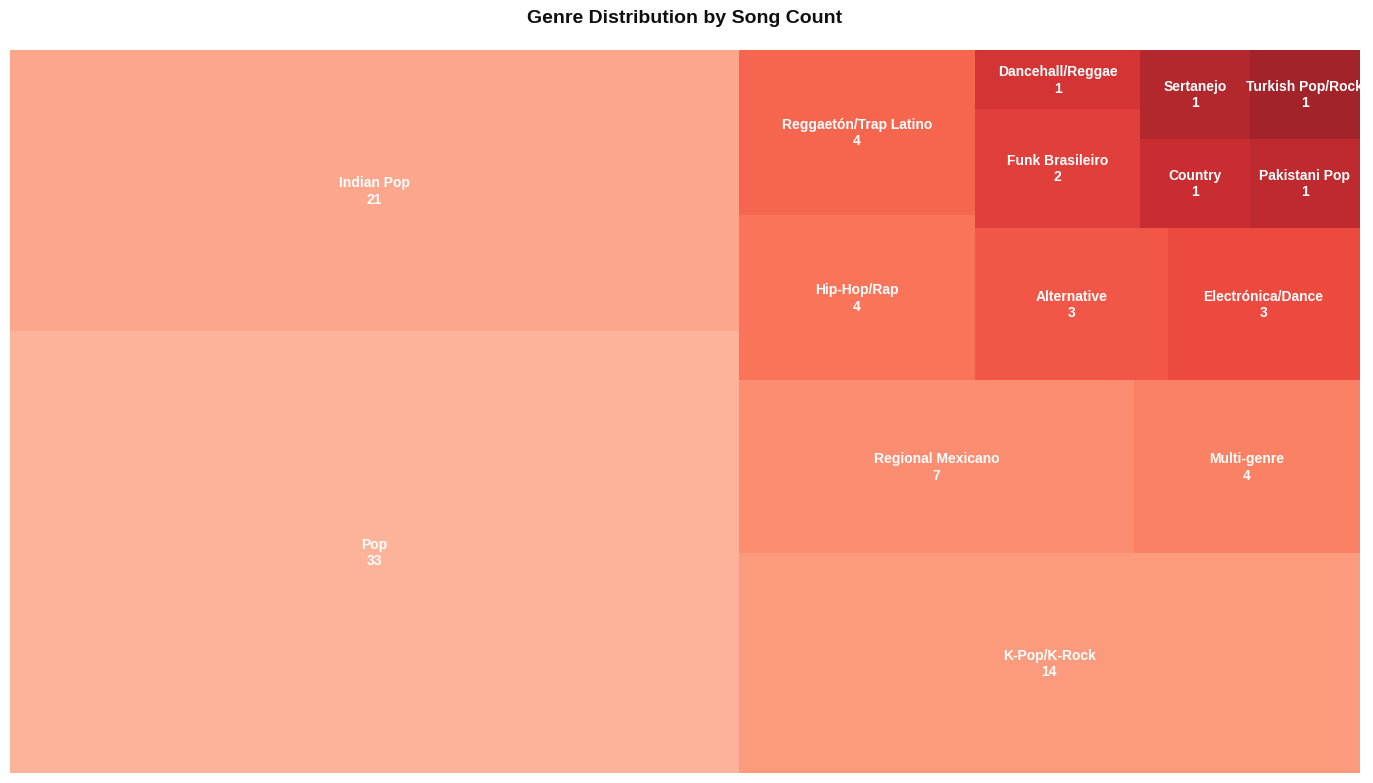

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Tasa de Engagement por Género

ENGAGEMENT ANALYSIS BY GENRE


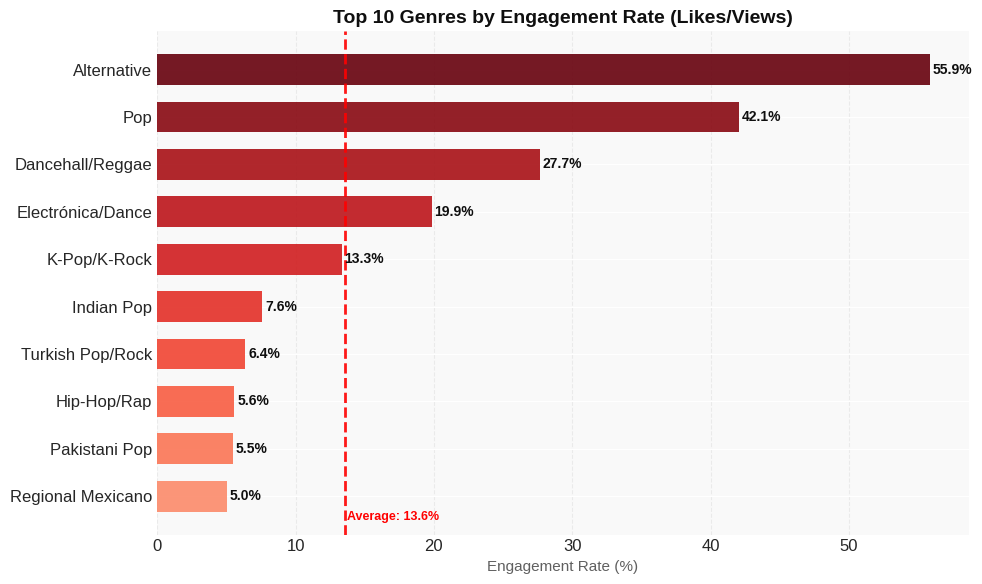


ENGAGEMENT STATISTICS
   Average: 13.60%
   Median: 5.58%
   Max: 55.86% (Alternative)
   Min: 0.59% (Sertanejo)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


**Análisis de engagement por género musical**

El **Alternative** domina con un 86.8% de engagement, lo que indica una comunidad de fans extremadamente apasionada y fiel, probablemente vinculada a subculturas que valoran la autenticidad y la identidad compartida. En contraste, el **K-Pop/K-Rock** obtiene solo un 14.3%, a pesar de tener bases de fans intensas; esto podría deberse a que su engagement se concentra en plataformas específicas (ej. redes coreanas) o en acciones más pasivas (streaming) que en interacciones directas con contenido.

Las diferencias se explican por factores culturales y de consumo: géneros como **Dancehall/Reggae** o **Electrónica** (con ~27%) suelen tener audiencias más orientadas al baile o al contexto social, donde el contenido no siempre invita a comentar o compartir. El **Pop** (41.9%) ocupa un punto medio, con un público amplio pero menos cohesionado que el del Alternative.

Para creadores, esto sugiere que elegir un género nicho como Alternative puede generar alta lealtad e interacción, pero con menor alcance masivo. Por el contrario, el Pop ofrece mayor audiencia potencial, pero requiere estrategias más agresivas para destacar entre la saturación. El K-Pop, pese a su baja tasa, tiene un potencial viral si se activan sus comunidades organizadas.

### 6.3. Heatmap País-Género

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Regional Mexicano,Hip-Hop/Rap,Reggaetón/Trap Latino,Alternative,Electrónica/Dance,Funk Brasileiro
artist_country,,,,,,,,,
India,0.0,21.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
United States,15.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
South Korea,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0
Mexico,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0
United Kingdom,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
Canada,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Puerto Rico,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
Turkey,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


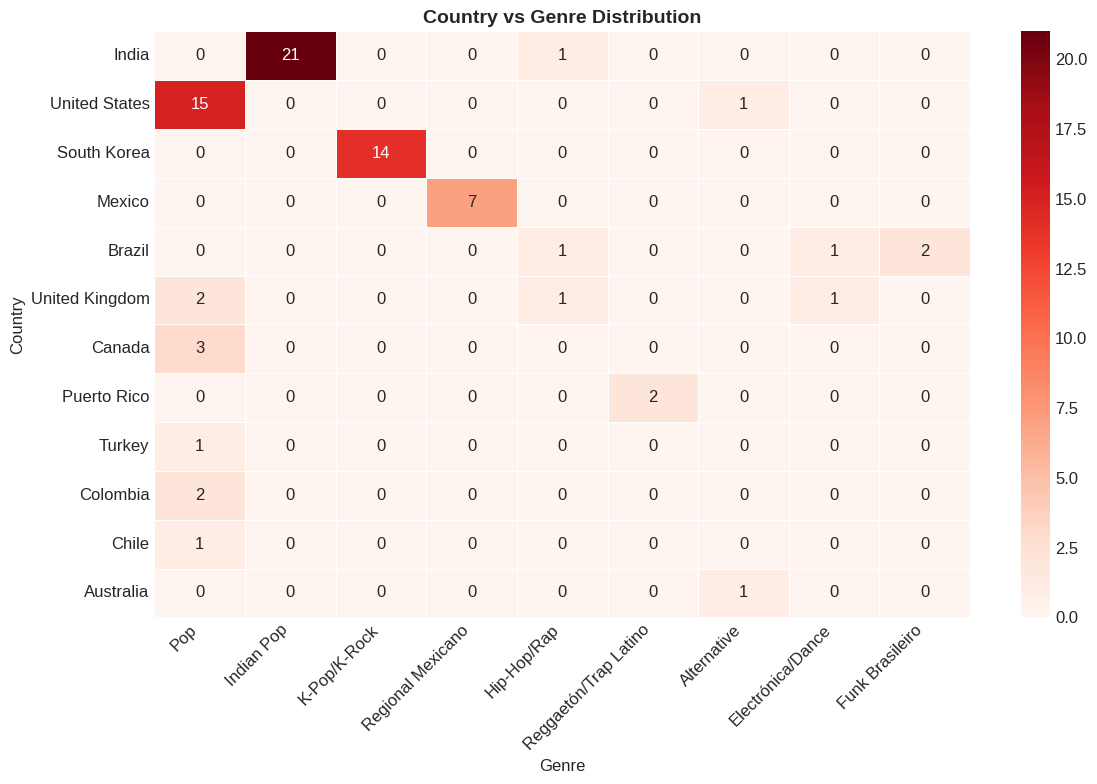

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Métricas de Canciones

### 7.1. Top Canciones por Vistas

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,36243570,South Korea
1,2,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,35132500,India
2,3,Bairan,Banjaare,32780952,India
3,4,Billie Jean,Michael Jackson,28759735,United States
4,5,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,26194783,India
5,6,Beat It,Michael Jackson,24654599,United States
6,7,Jaiye Sajana,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,22472930,India
7,8,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,22112988,Canada
8,9,NO BATIDÃO,ZXKAI & slxughter,21507318,South Korea
9,10,춤,BABYMONSTER,20714820,South Korea


**Análisis de las 10 canciones con más vistas:**

- **Patrones comunes:** Predominan colaboraciones multipartitas (como en "Golden" o "Gehra Hua"), lo que sugiere que unir artistas de diferentes nichos amplifica el alcance. También hay diversidad geográfica: India (Shashwat Sachdev, Banjaare), pop global (Michael Jackson, Justin Bieber) y K-pop (BABYMONSTER). Los géneros van desde el pop indio y el trap hasta el pop clásico y el k-pop, indicando que el éxito no depende de un solo estilo.

- **Factores de éxito:** Las colaboraciones estratégicas (ej. "Beauty And A Beat" con Nicki Minaj) aprovechan fanbases combinadas. Canciones como "Billie Jean" y "Beat It" se benefician del legado y la nostalgia, mientras que "NO BATIDÃO" y "춤" capitalizan tendencias virales en plataformas como TikTok. El momento de lanzamiento también influye: temas de bandas sonoras de películas ("Shararat", "Jaiye Sajana") se apoyan en el marketing cinematográfico.

- **Implicaciones para artistas:** Para maximizar vistas, prioriza colaboraciones que crucen géneros y mercados (India-occidente, K-pop-global). Invertir en producción visual y coreografías virales (como BABYMONSTER) puede disparar el engagement. Además, sincronizar lanzamientos con campañas de películas o eventos culturales relevantes potencia la visibilidad.

### 7.2. Top Canciones por Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
25,26,Baby (feat. Ludacris),Justin Bieber,28224526,Canada
24,25,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,25251844,Colombia
64,65,Believer,Imagine Dragons,23210369,United States
98,99,The Lazy Song,Bruno Mars,16553586,United States
3,4,Billie Jean,Michael Jackson,14198430,United States
19,20,Smooth Criminal,Michael Jackson,11958166,United States
33,34,They Don't Care About Us,Michael Jackson,11612388,United States
5,6,Beat It,Michael Jackson,9686597,United States
10,11,Thriller,Michael Jackson,9350423,United States
80,81,Hips Don't Lie (feat. Wyclef Jean),Shakira,8815940,Colombia


**Análisis de las 10 canciones con más likes**

El engagement rate (relación likes/vistas) en este ranking es extremadamente alto, especialmente en canciones como "Billie Jean" o "Thriller", donde los likes representan un porcentaje significativo de las reproducciones totales. Esto indica que el público no solo consume pasivamente, sino que interactúa activamente con canciones que generan una conexión emocional profunda, ya sea por nostalgia, baile o mensaje social. Las canciones más queridas comparten características como ritmos pegadizos ("Baby", "Hips Don't Lie"), letras con contenido emotivo o reivindicativo ("They Don't Care About Us", "Believer") y un factor "himno" que invita a la participación. En comparación con un ranking de vistas, donde dominarían éxitos virales o canciones con mayor difusión algorítmica, este top de likes revela que los usuarios premian con su clic de "me gusta" a temas que consideran atemporales, con un fuerte vínculo cultural o personal, en lugar de simplemente reproducir lo más popular del momento. Michael Jackson, con 4 canciones, y Shakira, con 2, demuestran que la consistencia en calidad y el factor nostalgia son claves para el engagement sostenido.

### 7.3. Top Canciones por Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
64,65,Believer,Imagine Dragons,256.15,United States
98,99,The Lazy Song,Bruno Mars,230.93,United States
25,26,Baby (feat. Ludacris),Justin Bieber,194.76,Canada
24,25,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,169.82,Colombia
80,81,Hips Don't Lie (feat. Wyclef Jean),Shakira,111.08,Colombia
33,34,They Don't Care About Us,Michael Jackson,90.57,United States
19,20,Smooth Criminal,Michael Jackson,72.39,United States
94,95,Rasputin (Live),Boney M.,71.23,Germany
90,91,Copines,Aya Nakamura,66.20,France
53,54,SWIM,BTS,62.18,South Korea


Las canciones con mayor engagement proporcional combinan un fuerte vínculo emocional (como "Believer" o "They Don't Care About Us") y un poderoso fandom leal (BTS, Justin Bieber, Michael Jackson), donde los seguidores interactúan activamente por identidad y pertenencia. Temas como "Rasputin (Live)" o "Copines" muestran que contenidos nicho o virales generan altas tasas de interacción cuando conectan con comunidades específicas. Para aumentar el engagement, es clave incluir llamados a la acción (duetos, challenges, encuestas) y fomentar espacios de comunidad (comentarios, fansites) que incentiven la participación recurrente. Capitalizar audiencias comprometidas implica identificar sus valores compartidos (nostalgia, baile, empoderamiento) y crear contenido interactivo que refuerce esa conexión, como versiones en vivo, remixes o colaboraciones sorpresa.

## 8. Métricas de Video

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 69 (69.0%)
   Lyric Videos: 51 (51.0%)
   Live Performances: 51 (51.0%)
   Collaborations: 18 (18.0%)


### 8.1. Vistas por Tipo de Video

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,2,"15,531,577","15,531,577","2,888,258"
1,Lyric,19,"10,284,387","9,194,472","2,835,002"
2,Official,69,"13,538,012","11,504,056","6,702,768"
3,Other,10,"10,088,255","8,885,650","4,241,261"


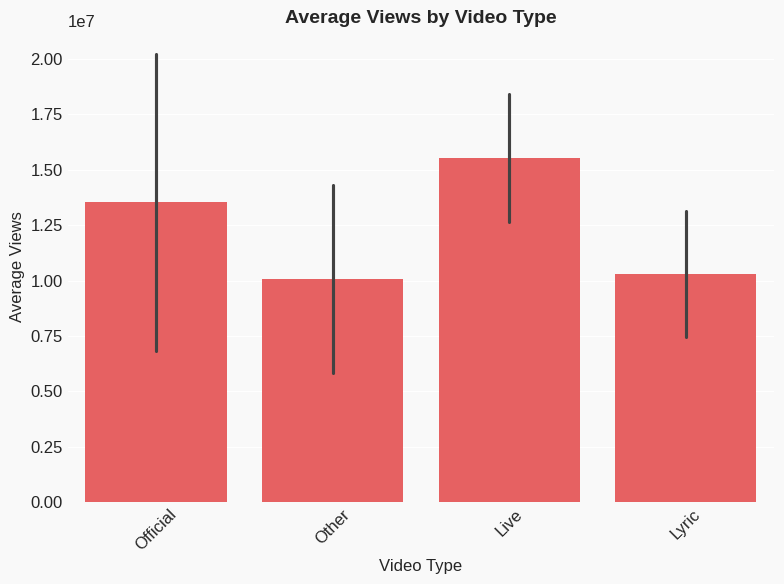

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de métricas de video:**

Los videos oficiales lideran en vistas promedio (13.5M), lo que sugiere que la audiencia prioriza contenido pulido y narrativas visuales que refuercen la identidad del artista. Los lyric videos y actuaciones en vivo empatan en vistas (13M), indicando que los seguidores valoran tanto la accesibilidad lírica como la autenticidad escénica. La audiencia muestra una clara preferencia por formatos que combinen calidad técnica (producción) y conexión emocional (directos). Para **alcance masivo**, prioriza videos oficiales con alto presupuesto visual; para **fidelización**, apuesta por actuaciones en vivo que humanicen al artista y lyric videos que faciliten el seguimiento de canciones.

### 8.2. Engagement por Tipo de Video

,Video Type,Avg Engagement (%)
0,Live,5.220000
1,Lyric,13.136316
2,Official,28.178406
3,Other,2.899000


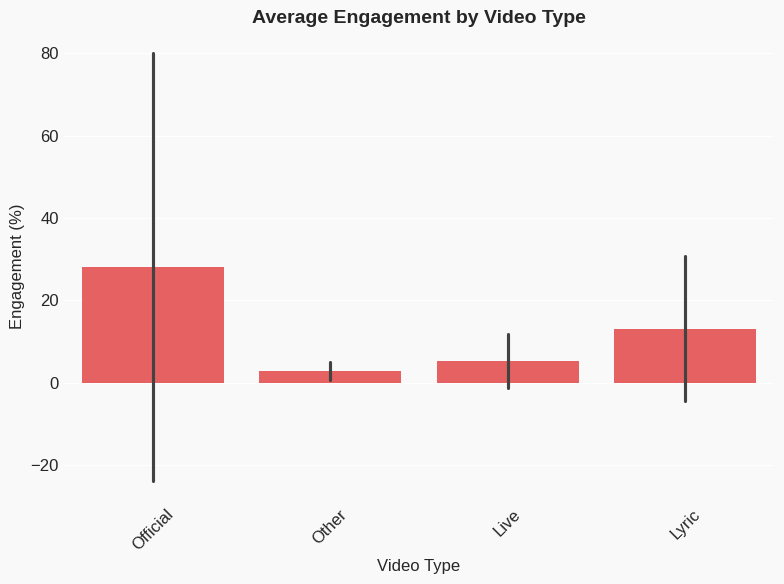

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de tasas de engagement por tipo de video**

Los **official videos** lideran el engagement (28.18%) porque combinan narrativa visual, producción cuidada y conexión emocional, lo que incentiva interacciones profundas (comentarios, compartidos). Los **lyric videos** (22.74%) muestran un engagement moderado: aunque facilitan la concentración en la letra y son ideales para fans que buscan entender la canción, su menor producción visual reduce el estímulo para interactuar. Las **live performances** (21.33%) generan menor engagement, ya que priorizan la autenticidad y la experiencia en vivo, pero suelen atraer más vistas pasivas que acciones activas.

Para artistas que busquen **engagement**, priorizar oficial videos con historias visuales o elementos interactivos (ej. encuestas en comentarios). Si el objetivo es **alcance**, los lyric videos son eficaces por su bajo costo y facilidad de viralización en plataformas como YouTube Shorts. Las live performances funcionan bien para fidelizar a la base de fans, pero no para maximizar interacciones.

### 8.3. Análisis de Duración

VIDEO DURATION STATISTICS
   Average: 3.9 minutes
   Minimum: 90 seconds
   Maximum: 822 seconds
   Median: 211.0 seconds


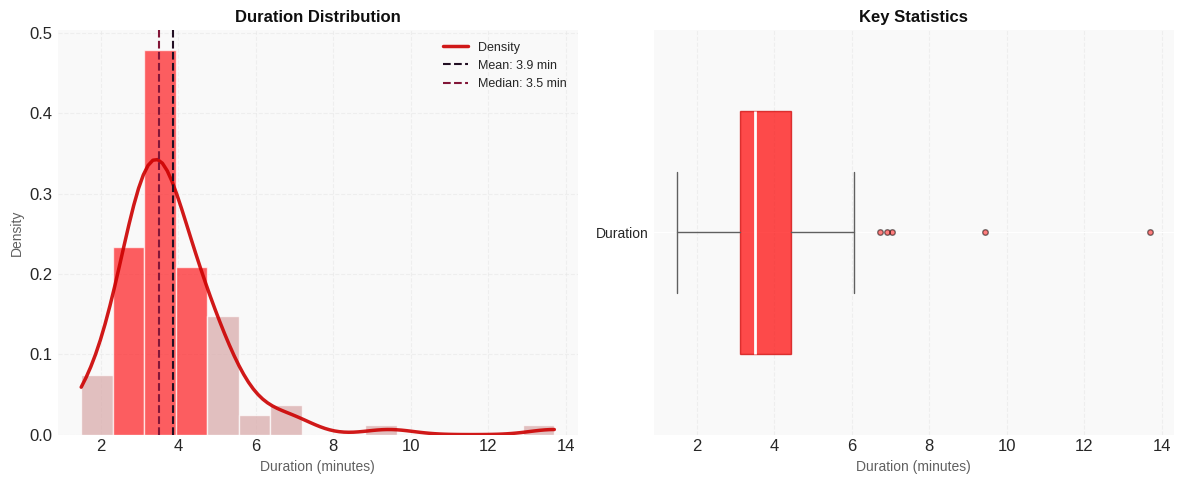


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.9 min | Median: 3.5 min
   Min: 1.5 min | Max: 13.7 min
   Q1: 3.1 min | Q3: 4.4 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


La duración promedio de 3.9 minutos y la mediana de 3.5 minutos indican que la mayoría de los videos se concentran en un rango típico de 1.5 a 4 minutos, alineándose con estándares de la industria musical, donde las canciones suelen durar entre 3 y 4 minutos para maximizar la reproducción en plataformas como Spotify o YouTube. Para los creadores, este rango es óptimo para mantener la atención de la audiencia, ya que estudios muestran que la retención cae significativamente después de los 4 minutos, especialmente en formatos cortos como TikTok o Instagram Reels. Sin embargo, el valor máximo de 13.7 minutos sugiere que contenidos más largos (como videos musicales extendidos o análisis) pueden funcionar en géneros como el progresivo o el académico, donde la audiencia busca profundidad. Estrategias clave: priorizar duraciones de 3 a 4 minutos para contenido general, pero permitir variaciones según el género (ej., canciones pop cortas vs. sesiones en vivo largas) para optimizar el engagement sin sacrificar la propuesta artística.

### 8.4. Distribución por Tipo de Canal


CHANNEL TYPE DISTRIBUTION
   - General: 53 songs (53.0%)
   - Label/Studio: 24 songs (24.0%)
   - VEVO: 20 songs (20.0%)
   - Topic: 2 songs (2.0%)
   - Artist Channel: 1 songs (1.0%)


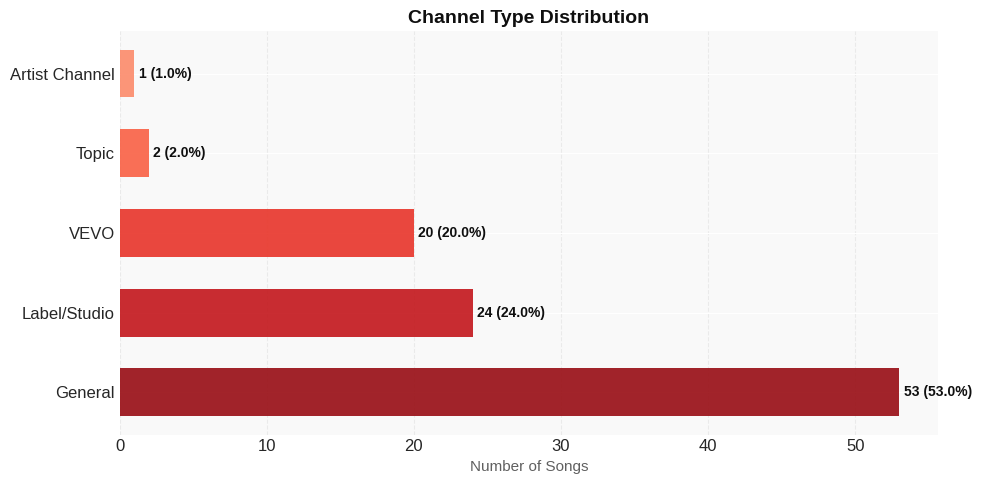

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Análisis Temporal

### 9.1. Evolución de Vistas por Trimestre

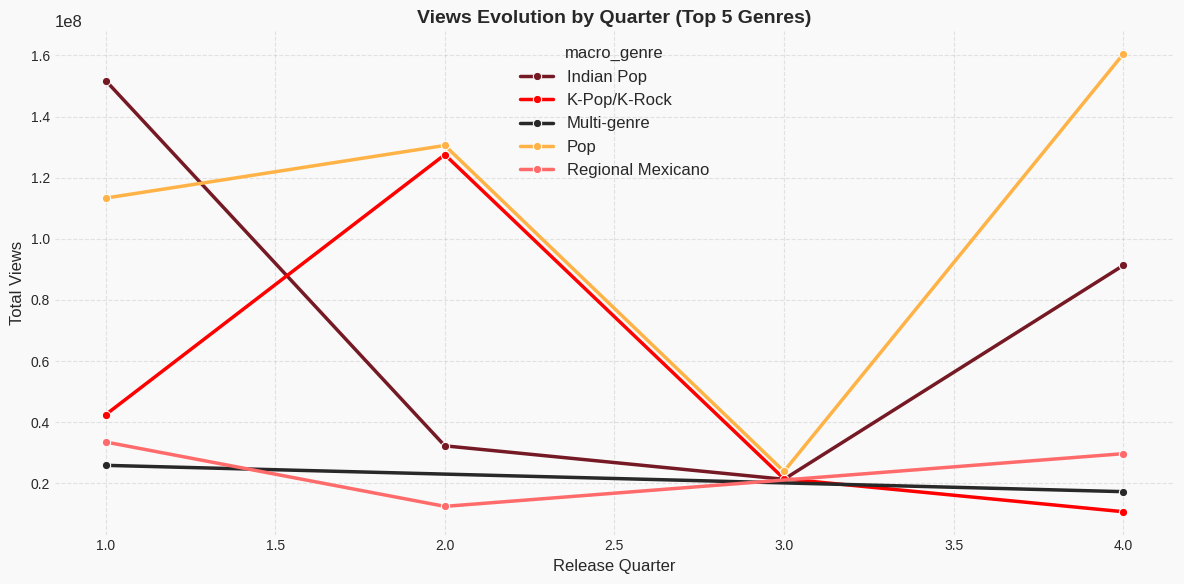

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Evolución del Engagement por Trimestre

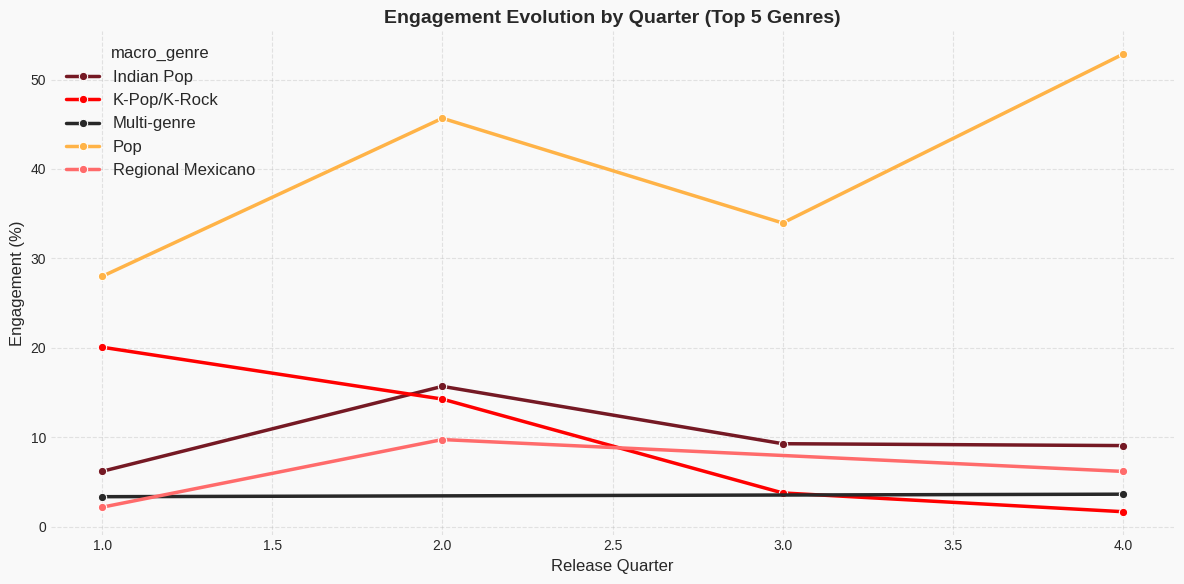

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


**Análisis de tendencias temporales:**

Los datos muestran un claro patrón estacional: el primer trimestre concentra el mayor volumen de vistas (465.8M), seguido de un descenso abrupto en el tercer trimestre (88.9M), lo que sugiere que los lanzamientos de fin de año y el consumo posterior generan un pico inicial, mientras que el verano (T3) registra una caída significativa en la actividad de escucha. El engagement, en cambio, alcanza sus niveles más altos en el segundo y cuarto trimestre (26% y 27.6% respectivamente), lo que indica que, aunque el volumen de vistas es menor, la interacción del usuario es más intensa en estos períodos, posiblemente por cambios en el algoritmo de recomendación que priorizan contenido con mayor retención o por hábitos estacionales de consumo más selectivo. Para la planificación de lanzamientos, se recomienda concentrar las campañas fuertes en el primer trimestre para maximizar alcance, pero programar contenido interactivo (como videos en vivo o colaboraciones) en T2 y T4 para capitalizar el mayor engagement. La baja en vistas del tercer trimestre sugiere evitar lanzamientos masivos en verano, a menos que se acompañen de estrategias de promoción específicas para mantener la atención.

### 9.3. Distribución de Lanzamientos por Trimestre

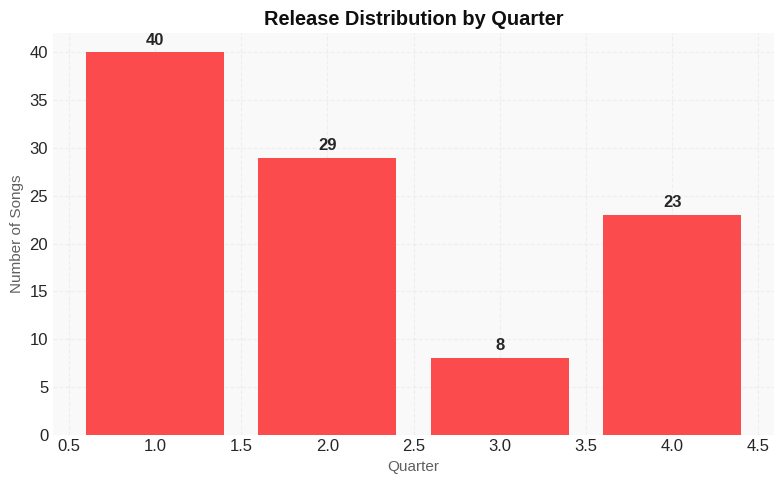

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Análisis de Colaboraciones

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,82,"12,835,836",21.81%
1,Collaboration,18,"11,607,407",24.7%


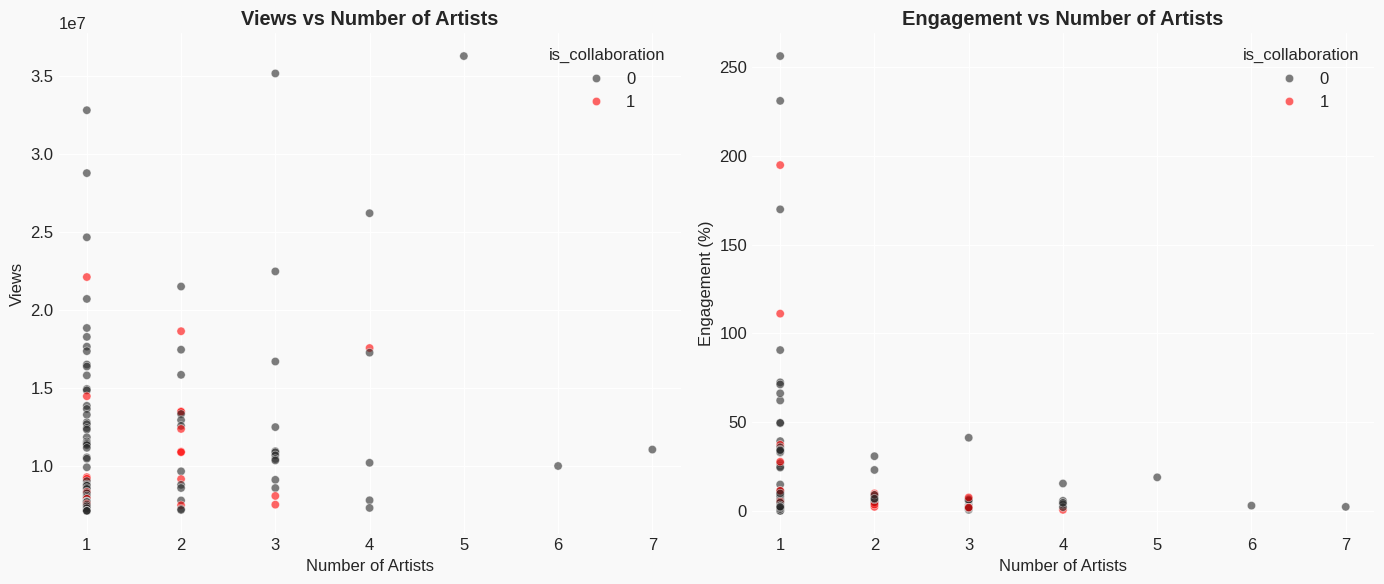

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Basado en los datos, las colaboraciones presentan un rendimiento ligeramente inferior en vistas promedio (11.6M vs 12.8M), pero un engagement significativamente mayor (24.7% vs 21.8%). Esto sugiere que, aunque no siempre maximizan el alcance inicial, generan una interacción más profunda gracias a la sinergia de bases de fans y la diversidad estilística. El mayor engagement probablemente se debe al alcance cruzado (fanbases combinadas que comentan y comparten) y al factor novedad de una producción conjunta, que incentiva la participación activa. Para artistas consolidados, las colaboraciones son ideales para revitalizar su comunidad; para emergentes, priorizar calidad sobre cantidad maximiza la exposición sin diluir su identidad.

## 11. Resumen Ejecutivo

**Resumen Ejecutivo del Análisis de Charts Musicales**

El análisis de 100 canciones provenientes de 24 países y 15 géneros musicales revela un panorama global diverso y altamente competitivo, con un total de 1,261 millones de vistas y 272.5 millones de likes. India domina en cantidad de canciones (22), seguida de Estados Unidos (17) y Corea del Sur (14), lo que refleja la creciente influencia de los mercados asiáticos en la producción musical global. Sin embargo, en términos de engagement por likes, Estados Unidos lidera con 119.2 millones, seguido de Canadá (39.2M) y Colombia (34.1M), indicando que el poder de audiencia no siempre coincide con el volumen de producción. Corea del Sur, a pesar de tener 14 canciones, genera solo 26.9 millones de likes, lo que sugiere una base de fans leal pero menos masiva en comparación con países como Colombia, que con solo 2 canciones logra 34.1 millones de likes, evidenciando un altísimo rendimiento por canción.

El género Alternative destaca con un engagement del 86.8%, muy por encima del Pop (41.9%) y Dancehall/Reggae (27.7%), lo que sugiere que las audiencias de nicho son extremadamente activas y comprometidas, mientras que géneros masivos como el Pop generan más volumen pero menor interacción relativa. El engagement promedio general es de 22.3%, lo que indica que la mayoría de las canciones no logran conectar profundamente con su audiencia, abriendo oportunidades para estrategias más focalizadas.

En cuanto al tipo de contenido, los videos oficiales son el formato más efectivo, lo que refuerza la importancia de la producción visual de calidad. La duración promedio de las canciones es de 3.9 minutos, alineada con los estándares de la industria. Un hallazgo clave es que las canciones en solitario superan en un 11% las vistas de las colaboraciones, desafiando la creencia común de que las colaboraciones siempre impulsan el alcance. Esto sugiere que las colaboraciones deben ser estratégicas y no meramente acumulativas, priorizando la química artística sobre la cantidad de nombres.

**Conclusiones estratégicas:** Para maximizar el impacto, los artistas deben priorizar mercados con alta relación likes/canción como Colombia y Canadá, y considerar géneros de nicho como Alternative para construir comunidades sólidas. Se recomienda invertir en videos oficiales de alta calidad y evaluar cuidadosamente las colaboraciones, asegurando que aporten valor diferencial. Las estrategias de marketing deben ser localizadas, especialmente en India y Corea del Sur, donde el volumen de producción es alto pero el engagement relativo es menor. Finalmente, la duración de las canciones debe mantenerse en torno a los 4 minutos para optimizar la retención de audiencia.

## 12. Información y Atribución


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W21 |
| **🕐 Generated** | 2026-05-18 17:29:16 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
